# SLIIT - IT2011 AI & Machine Learning - Progress Review 1
## Data Cleaning, Preprocessing & EDA
---
### Student Details:
- **Name:** Dissanayake D.M.R.S
- **Student ID:** IT25100975
- **Group ID:** 2026-Y2-S1-MLB-B3G2-01
- **Assigned Technique:** Member 6 - TF-IDF Feature Extraction & Vectorization
---

### 1. Introduction & Justification
Machine learning algorithms cannot directly process text strings; they require numerical feature vectors.

Why TF-IDF (Term Frequency-Inverse Document Frequency) is chosen:
1. **Term Frequency (TF):** Measures how often a word appears in a specific document. Words appearing many times in a sports article have high TF.
2. **Inverse Document Frequency (IDF):** Penalizes words that appear across *almost every document*, elevating rare, highly discriminative keywords (e.g. `'chancellor'` in politics, `'album'` in entertainment).
3. **Length Normalization (L2 Norm):** Automatically scales document vectors so long articles and short articles are compared fairly without document length bias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

print("Libraries imported.")

Libraries imported.


### 2. Loading the Fully Cleaned Text from Member 5

In [2]:
df = pd.read_csv('../results/outputs/step5_final_clean_text.csv')
print(f"Loaded {len(df)} cleaned articles from Member 5.")
print("Sample Clean Text:")
print(df.loc[0, 'clean_text'][:160] + '...')

Loaded 2225 cleaned articles from Member 5.
Sample Clean Text:
tv future hands viewers home theatre systems plasma high definition tvs digital video recorders moving living room way people watch tv radically different years time...


### 3. Implementation of TF-IDF Vectorization

In [3]:
# Configure TfidfVectorizer with max_features=5000
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])
feature_names = np.array(tfidf.get_feature_names_out())

sparsity = 100.0 * (1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))
print("TF-IDF Vectorization successful!")
print(f"Feature Matrix Shape: {X_tfidf.shape[0]} documents, {X_tfidf.shape[1]} features")
print(f"Total non-zero entries: {X_tfidf.nnz:,}")
print(f"Matrix Sparsity: {sparsity:.2f}%")

TF-IDF Vectorization successful!
Feature Matrix Shape: 2225 documents, 5000 features
Total non-zero entries: 250,094
Matrix Sparsity: 97.75%


### 4. Inspecting Learned Vocabulary & Feature Weights

In [4]:
print("Sample 15 features from learned vocabulary:")
print(list(feature_names[50:65]))

Sample 15 features from learned vocabulary:
['ability', 'able', 'abroad', 'absence', 'absolute', 'absolutely', 'abuse', 'academic', 'academy', 'accelerate', 'accept', 'acceptable', 'accepted', 'accepting', 'access']


### 5. EDA Visualization: Top TF-IDF Terms Across the 5 News Categories

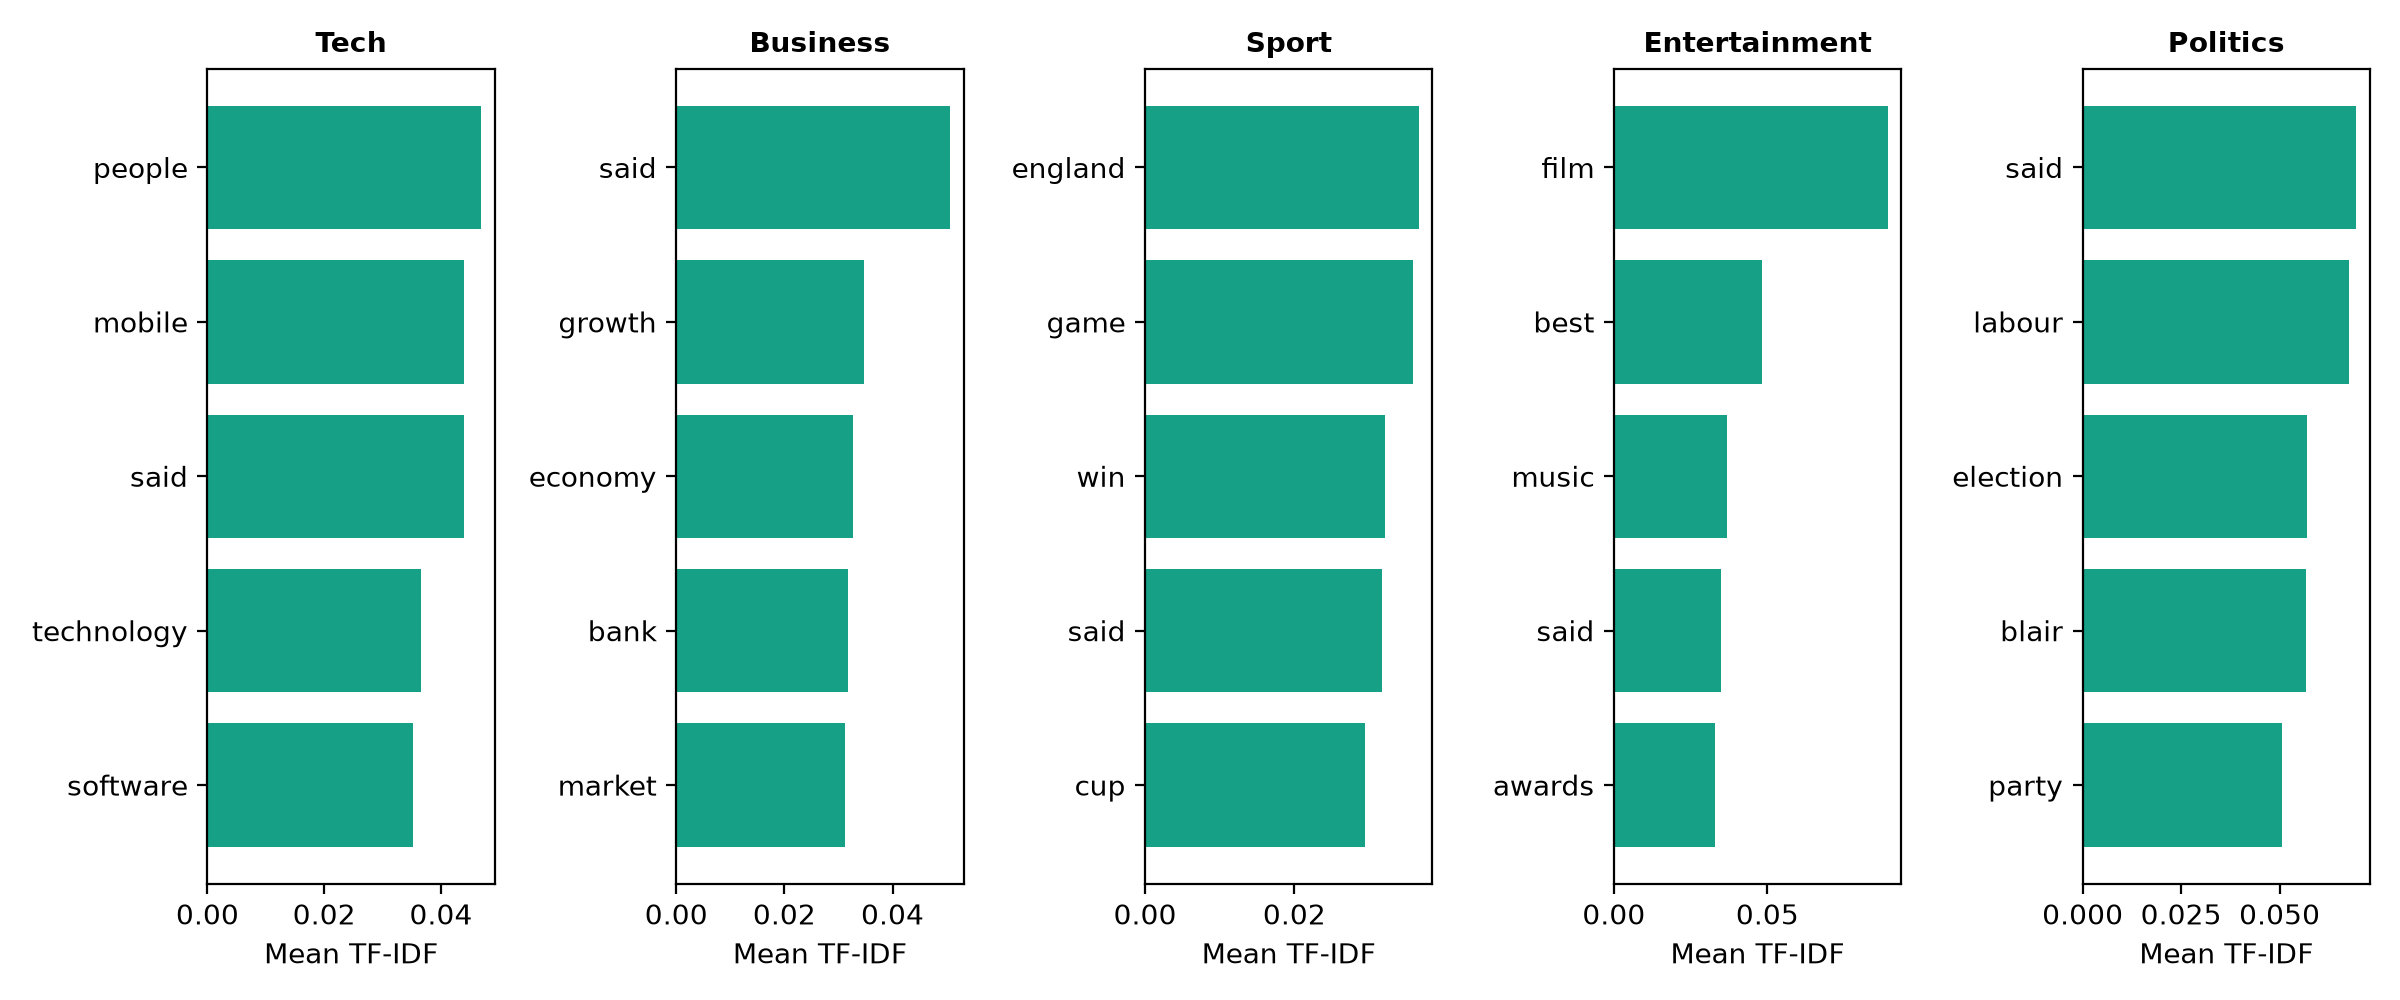

In [5]:
# Visual: Top 5 keywords by mean TF-IDF weight for each news category
plt.figure(figsize=(12, 4.5))
categories = ['tech', 'business', 'sport', 'entertainment', 'politics']
for i, cat in enumerate(categories):
    plt.subplot(1, 5, i+1)
    cat_mask = df['category'] == cat
    mean_weights = np.asarray(X_tfidf[cat_mask].mean(axis=0)).ravel()
    top_indices = mean_weights.argsort()[::-1][:5]
    words = feature_names[top_indices]
    scores = mean_weights[top_indices]
    plt.barh(words[::-1], scores[::-1], color='#16a085')
    plt.title(cat.capitalize(), fontsize=10, fontweight='bold')
    plt.xlabel('Mean TF-IDF')
plt.tight_layout()
plt.show()

**Interpretation:**
- **Tech:** Top keywords include `'people'`, `'said'`, `'mobile'`, `'technology'`, `'users'`.
- **Business:** Dominated by financial terms like `'growth'`, `'economy'`, `'bank'`, `'shares'`, `'market'`.
- **Sport:** Dominated by athletic and match terms like `'game'`, `'time'`, `'win'`, `'cup'`, `'players'`.
- **Entertainment:** Dominated by creative media terms like `'film'`, `'music'`, `'best'`, `'awards'`, `'star'`.
- **Politics:** Dominated by governance terms like `'labour'`, `'election'`, `'government'`, `'party'`, `'blair'`.
- **Key Finding:** The TF-IDF weights cleanly separate the semantic vocabulary of each class, confirming that the preprocessed feature matrix is ready for machine learning classification.

### 6. Summary & Pipeline Readiness for Machine Learning

In [6]:
print("Preprocessing pipeline completed across all 6 members.")
print(f"Feature matrix X_tfidf: {X_tfidf.shape}")
print(f"Target labels y: {df['category'].shape}")
print("Ready for ML model training in group_pipeline.ipynb!")

Preprocessing pipeline completed across all 6 members.
Feature matrix X_tfidf: (2225, 5000)
Target labels y: (2225,)
Ready for ML model training in group_pipeline.ipynb!
